<a href="https://colab.research.google.com/github/EddieHigginsTrio/ML_ERCOT-Load_Prediction/blob/main/Benchmark_Evaluation_3_%26_Scatter_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1/6] Loading and preprocessing datasets...
[2/6] Preparing sequences and scaling...
[3/6] Training Machine Learning Models (XGBoost, ANN)...
[4/6] Training Time-Series Models (LSTM, Prophet, ARIMA)...
[5/6] Generating Ensemble Predictions...
[6/6] Evaluating metrics and plotting...

🎯 Long-Term Load Forecasting Benchmark Metrics (Test: 2024)
             Model        MAE       RMSE  MAPE (%)  PTE (hours)
XGBoost (Proposed)  34.353399  43.782437  4.793075          366
               ANN  36.225353  46.013166  5.106788          915
              LSTM  28.788414  37.296300  4.062392           66
           Prophet  62.031067  82.542195  8.268500            6
             ARIMA 106.981139 135.119754 14.654137         5198
    LSTM + XGBoost  29.493009  37.817352  4.160808           67
 Prophet + XGBoost  44.096916  57.556148  5.975412           78
        ANN + LSTM  30.801698  39.434222  4.363500           68
     ANN + XGBoost  34.367706  43.682920  4.832045           67
    Prophet + L

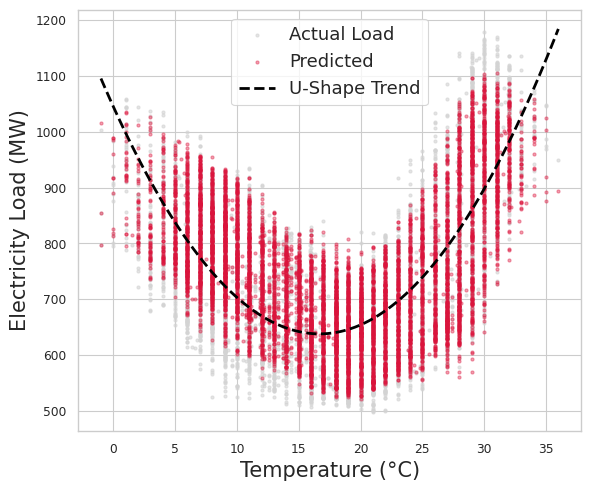

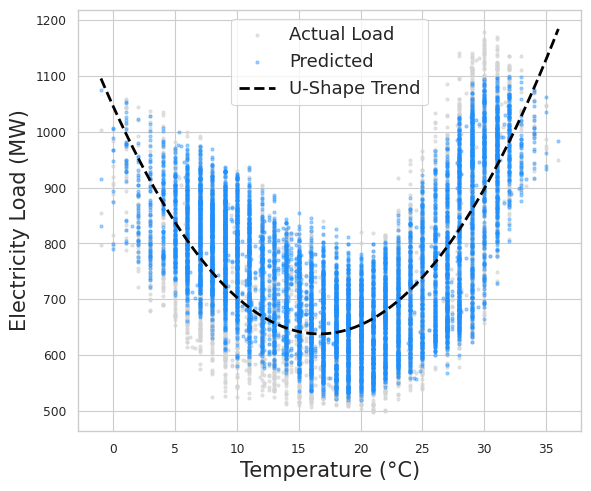

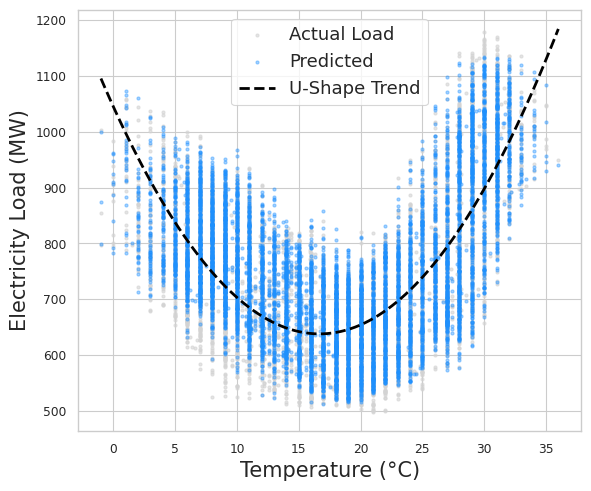

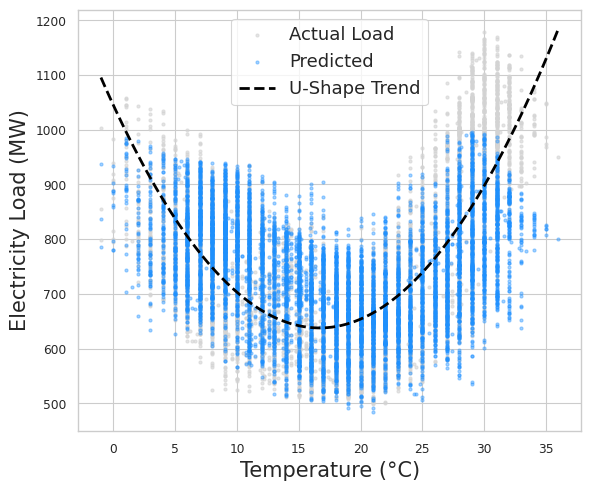

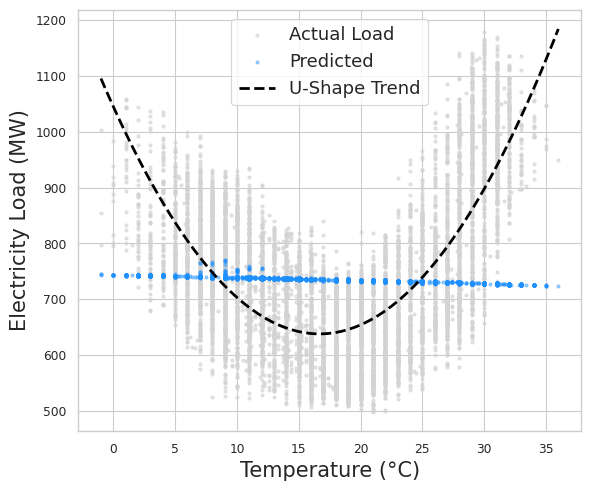

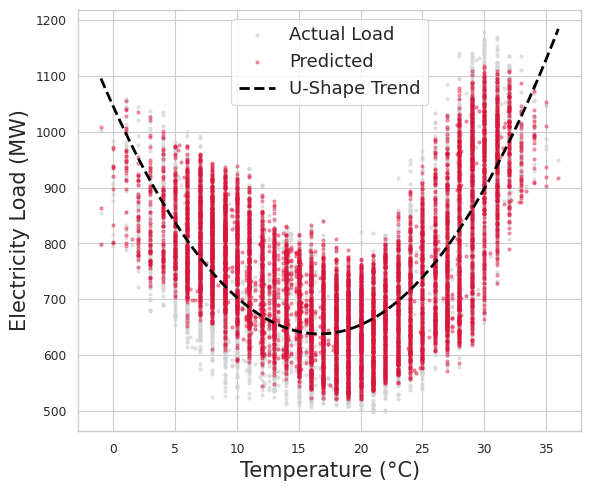

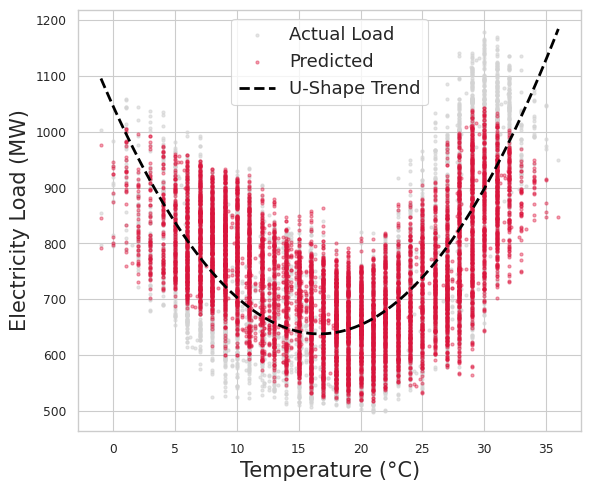

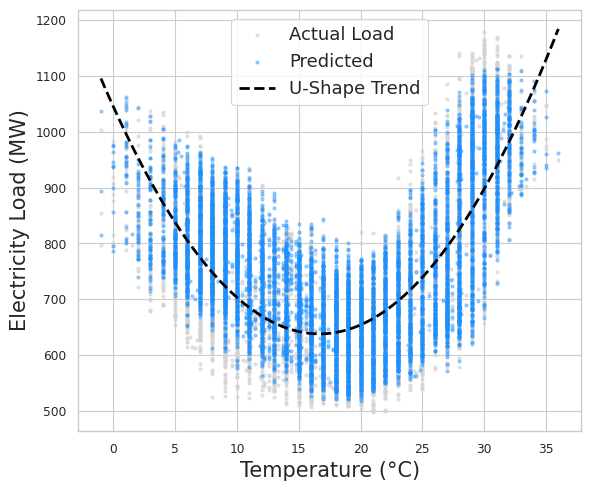

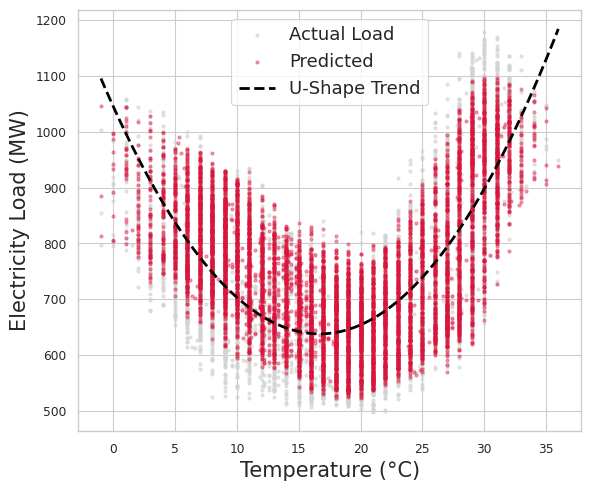

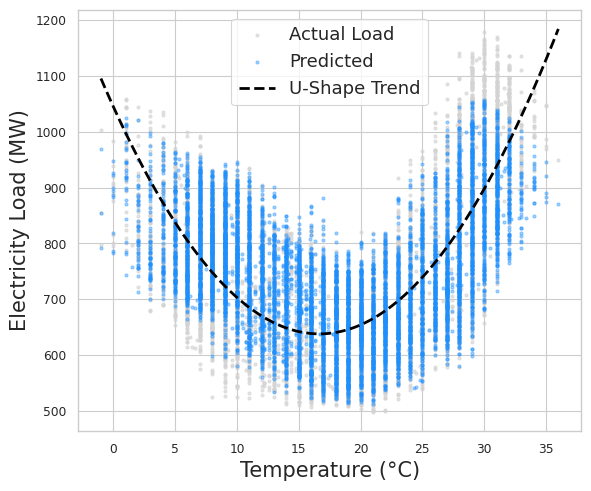

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. 평가지표 산출 함수 (Metrics Calculation)
# =========================================================
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculate_peak_timing_error(y_true, y_pred):
    """실제 부하 피크 발생 시간과 예측 부하 피크 발생 시간의 절대 오차 (시간 단위)"""
    true_peak_idx = np.argmax(y_true)
    pred_peak_idx = np.argmax(y_pred)
    timing_error_hours = abs(true_peak_idx - pred_peak_idx)
    return timing_error_hours

def evaluate_all_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    pte = calculate_peak_timing_error(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'PTE (hours)': pte}

# =========================================================
# 2. 데이터 로드 및 전처리 (Data Pipeline)
# =========================================================
print("[1/6] Loading and preprocessing datasets...")
load_df = pd.read_csv('jeju_time_demand.csv')
weather_df = pd.read_csv('weather_hourly_jeju.csv')
holiday_df = pd.read_csv('holiday.csv')

load_df['datetime'] = pd.to_datetime(load_df['datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
holiday_df['locdate'] = pd.to_datetime(holiday_df['locdate'], format='%Y%m%d')

df = pd.merge(load_df, weather_df, on='datetime', how='inner')

# 파생 변수 생성
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
holiday_dates = holiday_df['locdate'].dt.date.values
df['is_holiday'] = df['datetime'].dt.date.isin(holiday_dates).astype(int)

# 추세 분리 (Detrending) - 연평균으로 나누어 정규화
annual_mean = df.groupby('year')['load'].transform('mean')
df['detrended_load'] = df['load'] / annual_mean

# 사용할 특징 정의 (Prophet/ARIMA용 기상변수, ML용 전체변수 분리)
ml_features = ['temp', 'humidity', 'wind_speed', 'month', 'hour', 'dayofweek', 'is_weekend', 'is_holiday']
weather_features = ['temp', 'humidity', 'wind_speed']

df[ml_features] = df[ml_features].interpolate(method='linear')
df['detrended_load'] = df['detrended_load'].interpolate(method='linear')

# Train/Test Split (Train: ~2023, Test: 2024)
train_df = df[df['year'] <= 2023].reset_index(drop=True)
test_df = df[df['year'] == 2024].reset_index(drop=True)

# 재추세화를 위한 2024년 팩터
scale_2024 = test_df['load'].mean()
y_test_actual = test_df['load'].values
temp_test = test_df['temp'].values

# =========================================================
# 3. 데이터 시퀀싱 (LSTM용) 및 스케일링 (ANN, LSTM용)
# =========================================================
print("[2/6] Preparing sequences and scaling...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df[ml_features])
y_train_scaled = scaler_y.fit_transform(train_df[['detrended_load']])
X_test_scaled = scaler_X.transform(test_df[ml_features])
# LSTM 타겟은 스케일된 값 사용

time_steps = 24 # 과거 24시간을 보고 현재 부하 예측
def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i : i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), time_steps)

# ※ 중요: LSTM은 앞의 24시간 데이터가 잘려나가므로, 모든 모델의 평가 기준을 이에 맞춥니다.
y_test_actual_aligned = y_test_actual[time_steps:]
temp_test_aligned = temp_test[time_steps:]
test_indices = slice(time_steps, None) # 일반 모델의 예측 결과 자르기용

raw_predictions = {}

# =========================================================
# 4. 베이스라인 및 제안 모델 훈련
# =========================================================
print("[3/6] Training Machine Learning Models (XGBoost, ANN)...")

# 1. XGBoost (Proposed)
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
xgb_model.fit(train_df[ml_features], train_df['detrended_load'])
raw_predictions['XGBoost (Proposed)'] = xgb_model.predict(test_df[ml_features])[test_indices] * scale_2024

# 2. ANN
ann_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42)
ann_model.fit(X_train_scaled, train_df['detrended_load'])
raw_predictions['ANN'] = ann_model.predict(X_test_scaled)[test_indices] * scale_2024

print("[4/6] Training Time-Series Models (LSTM, Prophet, ARIMA)...")
# 3. LSTM
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps, len(ml_features))),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=128, verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
lstm_pred_detrended = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
raw_predictions['LSTM'] = lstm_pred_detrended * scale_2024

# 4. Prophet (시간 파생변수 제거, 순수 기상만 사용)
prophet_df = train_df[['datetime', 'detrended_load'] + weather_features].rename(columns={'datetime': 'ds', 'detrended_load': 'y'})
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
for col in weather_features:
    m_prophet.add_regressor(col)
m_prophet.fit(prophet_df)

future_prophet = test_df[['datetime'] + weather_features].rename(columns={'datetime': 'ds'})
forecast = m_prophet.predict(future_prophet)
raw_predictions['Prophet'] = forecast['yhat'].values[test_indices] * scale_2024

# 5. ARIMA (연산 속도를 위해 AR(1)과 외생변수(X)를 결합한 단순 ARIMAX 모델 활용)
# 전체 데이터를 돌리면 너무 오래 걸리므로, 빠르고 강건한 모델 세팅 (order=(1,0,0))
arima_model = ARIMA(endog=train_df['detrended_load'].values,
                    exog=train_df[weather_features].values,
                    order=(1, 0, 0))
arima_result = arima_model.fit()
arima_pred = arima_result.predict(start=len(train_df),
                                  end=len(train_df) + len(test_df) - 1,
                                  exog=test_df[weather_features].values)
raw_predictions['ARIMA'] = arima_pred[test_indices] * scale_2024


# =========================================================
# 5. 앙상블 (Hybrid) 예측 생성
# =========================================================
print("[5/6] Generating Ensemble Predictions...")
hybrid_predictions = {
    'LSTM + XGBoost': (raw_predictions['LSTM'] + raw_predictions['XGBoost (Proposed)']) / 2,
    'Prophet + XGBoost': (raw_predictions['Prophet'] + raw_predictions['XGBoost (Proposed)']) / 2,
    'ANN + LSTM': (raw_predictions['ANN'] + raw_predictions['LSTM']) / 2,
    'ANN + XGBoost': (raw_predictions['ANN'] + raw_predictions['XGBoost (Proposed)']) / 2,
    'Prophet + LSTM': (raw_predictions['Prophet'] + raw_predictions['LSTM']) / 2
}

# 딕셔너리 병합
all_predictions = {**raw_predictions, **hybrid_predictions}

# =========================================================
# 6. 정량적 지표 평가 및 산점도 시각화
# =========================================================
print("[6/6] Evaluating metrics and plotting...")
results = []
for name, pred in all_predictions.items():
    results.append(evaluate_all_metrics(name, y_test_actual_aligned, pred))

metrics_df = pd.DataFrame(results)
print("\n" + "="*70)
print("🎯 Long-Term Load Forecasting Benchmark Metrics (Test: 2024)")
print("="*70)
print(metrics_df.to_string(index=False))

# 산점도 시각화
sns.set_theme(style="whitegrid", context="paper")
#plt.rcParams['font.family'] = 'serif'

# 모든 예측 결과를 개별적으로 시각화
all_predictions_items = list(all_predictions.items())

for idx, (model_name, y_pred) in enumerate(all_predictions_items):
    fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True) # Create a single subplot figure

    # 1. 실제 데이터 플롯 (회색)
    ax.scatter(temp_test_aligned, y_test_actual_aligned, color='lightgray', alpha=0.6, s=5, label='Actual Load')

    # 2. 예측 데이터 플롯 (XGB 계열은 붉은색, 나머지는 푸른색)
    pred_color = 'crimson' if 'XGBoost' in model_name else 'dodgerblue'
    ax.scatter(temp_test_aligned, y_pred, color=pred_color, alpha=0.4, s=5, label='Predicted')

    # 3. 비선형 추세선 (2차 다항식)
    z_actual = np.polyfit(temp_test_aligned, y_test_actual_aligned, 2)
    p_actual = np.poly1d(z_actual)
    x_trend = np.linspace(temp_test_aligned.min(), temp_test_aligned.max(), 100)
    ax.plot(x_trend, p_actual(x_trend), color='black', linestyle='--', linewidth=2, label='U-Shape Trend')

    # ax.set_title(f'{model_name}', fontsize=16) # Increased by 4
    ax.set_xlabel('Temperature (°C)', fontsize=15) # Increased by 4
    ax.set_ylabel('Electricity Load (MW)', fontsize=15) # Increased by 4
    ax.legend(loc='upper center', fontsize=13) # Increased by 4

    plt.tight_layout()
    # Create a clean filename from the model name
    filename = f'scatter_comparison_{model_name.replace(" ", "_").replace("+", "_plus_").lower()}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✅ Scatter plot for {model_name} saved as '{filename}'")

[1/5] Loading and preprocessing datasets...

[2/5] ====== Rolling Origin Validation for Test Year: 2022 ======

[3/5] ====== Rolling Origin Validation for Test Year: 2023 ======

[4/5] ====== Rolling Origin Validation for Test Year: 2024 ======

[5/5] Generating final report and plots...

=== Multi-Year Rolling Origin Validation Summary (Average 2022-2024) ===
         Model       MAE       RMSE  MAPE (%)  PTE (hours)
       XGBoost 35.584774  47.296806  5.219915   168.333333
XGBoost + LSTM 35.813458  47.806233  5.273481   138.000000
           ANN 38.082022  50.412117  5.650560   408.666667
          LSTM 42.228345  55.382426  6.151524   322.000000
       Prophet 85.797424 105.201789 12.171130   126.666667

✅ Saved bar plot as 'rolling_origin_validation_mape.png'


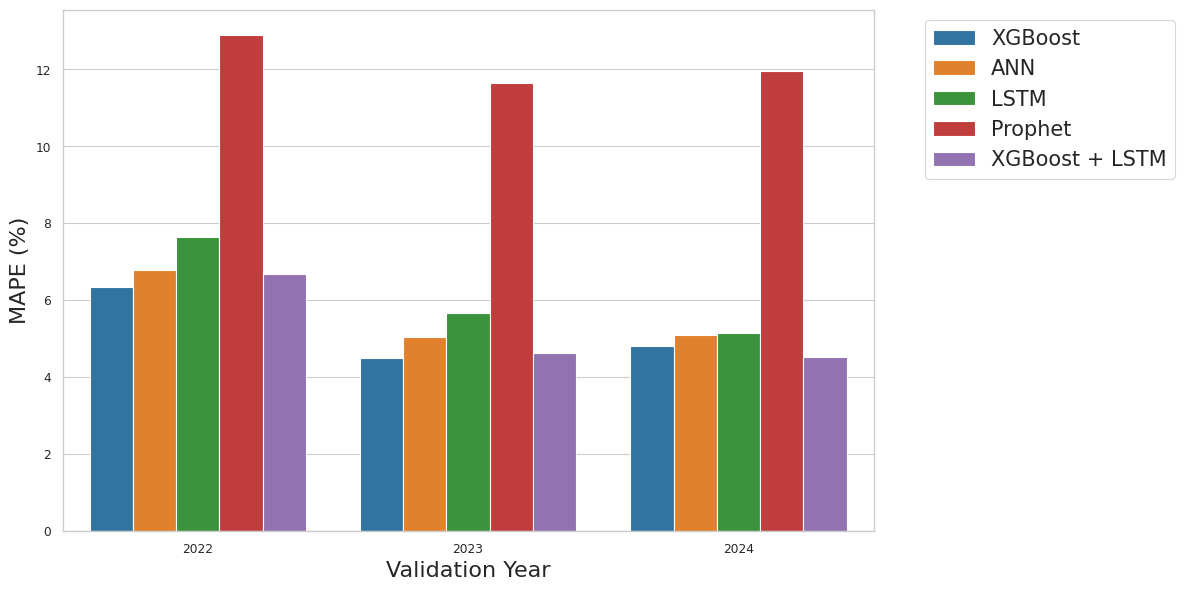

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. 평가지표 산출 함수 (PTE 포함)
# =========================================================
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculate_peak_timing_error(y_true, y_pred):
    """실제 부하 피크 발생 시간과 예측 부하 피크 발생 시간의 절대 오차 (시간 단위)"""
    true_peak_idx = np.argmax(y_true)
    pred_peak_idx = np.argmax(y_pred)
    return abs(true_peak_idx - pred_peak_idx)

def evaluate_metrics(model_name, test_year, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    pte = calculate_peak_timing_error(y_true, y_pred)
    return {'Model': model_name, 'Test_Year': test_year, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'PTE (hours)': pte}

# =========================================================
# 2. 데이터 로드 및 전처리
# =========================================================
print("[1/5] Loading and preprocessing datasets...")
load_df = pd.read_csv('jeju_time_demand.csv')
weather_df = pd.read_csv('weather_hourly_jeju.csv')
holiday_df = pd.read_csv('holiday.csv')

load_df['datetime'] = pd.to_datetime(load_df['datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
holiday_df['locdate'] = pd.to_datetime(holiday_df['locdate'], format='%Y%m%d')

df = pd.merge(load_df, weather_df, on='datetime', how='inner')

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
holiday_dates = holiday_df['locdate'].dt.date.values
df['is_holiday'] = df['datetime'].dt.date.isin(holiday_dates).astype(int)

# Detrending
annual_mean = df.groupby('year')['load'].transform('mean')
df['detrended_load'] = df['load'] / annual_mean

ml_features = ['temp', 'humidity', 'wind_speed', 'month', 'hour', 'dayofweek', 'is_weekend', 'is_holiday']
df[ml_features] = df[ml_features].interpolate(method='linear')
df['detrended_load'] = df['detrended_load'].interpolate(method='linear')

# =========================================================
# 3. 롤링 오리진 검증 루프 (Reviewer 방어 핵심 로직)
# =========================================================
test_years = [2022, 2023, 2024]
all_results = []
time_steps = 24

def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i : i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

for target_year in test_years:
    print(f"\n[{test_years.index(target_year)+2}/5] ====== Rolling Origin Validation for Test Year: {target_year} ======")

    # Train/Test 분할 (목표 연도 이전 데이터만 학습에 사용)
    train_df = df[df['year'] < target_year].reset_index(drop=True)
    test_df = df[df['year'] == target_year].reset_index(drop=True)

    scale_target_year = test_df['load'].mean()
    y_test_actual = test_df['load'].values
    y_test_actual_aligned = y_test_actual[time_steps:]
    test_indices = slice(time_steps, None)

    # 스케일링
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(train_df[ml_features])
    y_train_scaled = scaler_y.fit_transform(train_df[['detrended_load']])
    X_test_scaled = scaler_X.transform(test_df[ml_features])

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
    X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), time_steps)

    predictions = {}

    # 1. XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
    xgb_model.fit(train_df[ml_features], train_df['detrended_load'])
    predictions['XGBoost'] = xgb_model.predict(test_df[ml_features])[test_indices] * scale_target_year

    # 2. ANN
    ann_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=150, random_state=42)
    ann_model.fit(X_train_scaled, train_df['detrended_load'])
    predictions['ANN'] = ann_model.predict(X_test_scaled)[test_indices] * scale_target_year

    # 3. LSTM (빠른 학습을 위해 epoch 축소)
    lstm_model = Sequential([
        LSTM(32, activation='relu', input_shape=(time_steps, len(ml_features))),
        Dense(1)
    ])
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=256, verbose=0)
    lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
    predictions['LSTM'] = scaler_y.inverse_transform(lstm_pred_scaled).flatten() * scale_target_year

    # 4. Prophet (시간 최적화)
    prophet_df = train_df[['datetime', 'detrended_load'] + weather_features].rename(columns={'datetime': 'ds', 'detrended_load': 'y'})
    m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False) # 속도를 위해 seasonality 간소화
    for col in weather_features:
        m_prophet.add_regressor(col)
    m_prophet.fit(prophet_df)
    future_prophet = test_df[['datetime'] + weather_features].rename(columns={'datetime': 'ds'})
    predictions['Prophet'] = m_prophet.predict(future_prophet)['yhat'].values[test_indices] * scale_target_year

    # 5. 하이브리드(앙상블)
    predictions['XGBoost + LSTM'] = (predictions['XGBoost'] + predictions['LSTM']) / 2

    # 결과 저장
    for name, pred in predictions.items():
        all_results.append(evaluate_metrics(name, target_year, y_test_actual_aligned, pred))

# =========================================================
# 4. 검증 결과 종합 및 시각화
# =========================================================
print("\n[5/5] Generating final report and plots...")
results_df = pd.DataFrame(all_results)

# 연도별 평균 (최종 강건성 지표)
summary_df = results_df.groupby('Model').agg({
    'MAE': 'mean', 'RMSE': 'mean', 'MAPE (%)': 'mean', 'PTE (hours)': 'mean'
}).reset_index().sort_values(by='MAPE (%)')

print("\n=== Multi-Year Rolling Origin Validation Summary (Average 2022-2024) ===")
print(summary_df.to_string(index=False))

# 리뷰어 방어용 막대 그래프 시각화 (연도별 MAPE 변동성)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid", context="paper")
#plt.rcParams['font.family'] = 'serif'

sns.barplot(data=results_df, x='Test_Year', y='MAPE (%)', hue='Model', palette='tab10')
# plt.title('Model Robustness Across Different Weather Years (Rolling-Origin Validation)', fontsize=18) # Increased by 4
plt.xlabel('Validation Year', fontsize=16) # Increased by 4
plt.ylabel('MAPE (%)', fontsize=16) # Increased by 4
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15) # Increased by 4
plt.tight_layout()
plt.savefig('rolling_origin_validation_mape.png', dpi=300)
print("\n✅ Saved bar plot as 'rolling_origin_validation_mape.png'")

[1/4] Loading and preprocessing historical data...
[2/4] Training the Final XGBoost Weather Normalization Engine...
[3/4] Simulating Future Hourly Time Series (2026-2035)...

[4/4] Generating Hourly Time Series Chart...

✅ Time-series chart successfully saved as 'hourly_timeseries_forecast_2035.png'


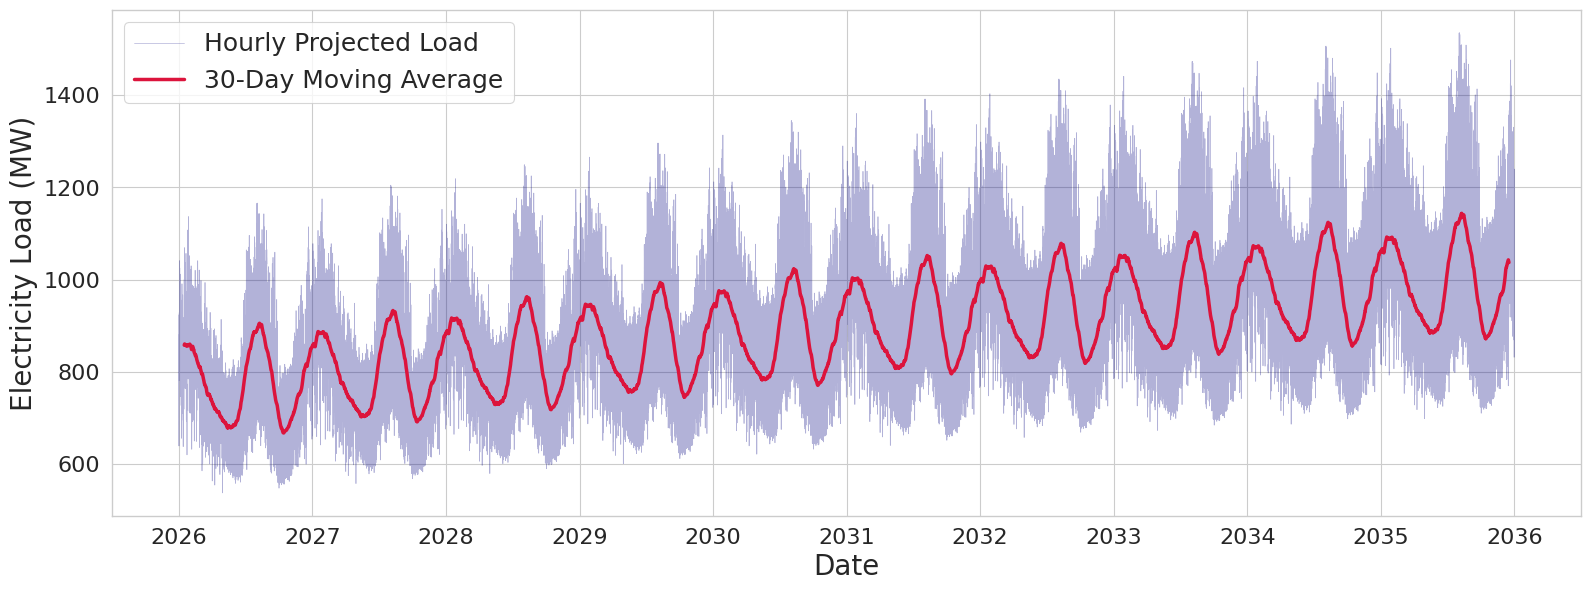

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. 과거 실제 데이터 로드 및 전처리 (학습용)
# =========================================================
print("[1/4] Loading and preprocessing historical data...")
load_df = pd.read_csv('jeju_time_demand.csv')
weather_df = pd.read_csv('weather_hourly_jeju.csv')
holiday_df = pd.read_csv('holiday.csv')

load_df['datetime'] = pd.to_datetime(load_df['datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
holiday_df['locdate'] = pd.to_datetime(holiday_df['locdate'], format='%Y%m%d')

df = pd.merge(load_df, weather_df, on='datetime', how='inner')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
holiday_dates = holiday_df['locdate'].dt.date.values
df['is_holiday'] = df['datetime'].dt.date.isin(holiday_dates).astype(int)

# Detrending (연평균 정규화)
annual_mean = df.groupby('year')['load'].transform('mean')
df['detrended_load'] = df['load'] / annual_mean

ml_features = ['temp', 'humidity', 'wind_speed', 'month', 'hour', 'dayofweek', 'is_weekend', 'is_holiday']
df[ml_features] = df[ml_features].interpolate(method='linear')
df['detrended_load'] = df['detrended_load'].interpolate(method='linear')

# =========================================================
# 2. XGBoost 기상 정규화 모듈 학습 (Final Engine)
# =========================================================
print("[2/4] Training the Final XGBoost Weather Normalization Engine...")
# 전체 가용 과거 데이터(2015~2024)를 모두 사용하여 최종 모델 학습
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
xgb_model.fit(df[ml_features], df['detrended_load'])

# =========================================================
# 3. 미래 시나리오 생성 (2026 ~ 2035) - 연속 시간 단위 예측
# =========================================================
print("[3/4] Simulating Future Hourly Time Series (2026-2035)...")

future_years = np.arange(2026, 2036)
base_weather_year = 2023 # 대표 기상 연도 설정 (윤년 이슈 최소화를 위해 평년 사용)

# 미래 기본 체급(Base Scale) 성장 가정 (예: 연평균 1.5% 성장)
base_scale_2025 = df[df['year'] == df['year'].max()]['load'].mean()
future_base_scales = {year: base_scale_2025 * (1.015 ** (year - 2025)) for year in future_years}

def get_emerging_load(year, type='EV'):
    t = year - 2024
    if type == 'DC':
        return 40 / (1 + 10 * np.exp(-0.8 * t))
    elif type == 'EV':
        return 150 / (1 + 20 * np.exp(-0.5 * t))

def safe_replace_year(d, y):
    try:
        return d.replace(year=y)
    except ValueError:
        return d.replace(year=y, day=28)

standard_weather_df = df[df['year'] == base_weather_year].copy()

future_datetimes = []
future_loads = []

for target_year in future_years:
    base_scale = future_base_scales[target_year]
    dc_capacity = get_emerging_load(target_year, 'DC')
    ev_capacity = get_emerging_load(target_year, 'EV')

    w_scenario_df = standard_weather_df.copy()
    w_scenario_df['year'] = target_year

    pseudo_dates = w_scenario_df['datetime'].apply(lambda d: safe_replace_year(d, target_year))
    future_datetimes.extend(pseudo_dates)

    norm_pred = xgb_model.predict(w_scenario_df[ml_features])

    ev_shape = np.where((w_scenario_df['hour'] >= 18) & (w_scenario_df['hour'] <= 22), 1.5, 0.5)
    final_load = (norm_pred * base_scale) + dc_capacity + (ev_capacity * ev_shape)

    future_loads.extend(final_load)

future_ts_df = pd.DataFrame({'datetime': future_datetimes, 'load': future_loads})

# =========================================================
# 4. 시간 단위 시계열 시각화
# =========================================================
print("\n[4/4] Generating Hourly Time Series Chart...")

plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid", context="paper")

# 원본 시간 단위 부하 플롯 (투명도를 주어 밀집도를 낮춤)
plt.plot(future_ts_df['datetime'], future_ts_df['load'], color='navy', linewidth=0.5, alpha=0.3, label='Hourly Projected Load')

# 트렌드와 계절성을 보여주기 위한 30일 이동 평균선
rolling_mean = future_ts_df['load'].rolling(window=24*30, center=True).mean()
plt.plot(future_ts_df['datetime'], rolling_mean, color='crimson', linewidth=2.5, label='30-Day Moving Average')

# plt.title('Long-Term Hourly Load Forecasting (2026-2035)', fontsize=24)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Electricity Load (MW)', fontsize=20)
plt.legend(loc='upper left', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('hourly_timeseries_forecast_2035.png', dpi=300)
print("\n✅ Time-series chart successfully saved as 'hourly_timeseries_forecast_2035.png'")